In [1]:
import argparse
import os
import sys

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import torch
torch.multiprocessing.set_start_method('spawn')

import jax
from lob.encoding import Vocab, Message_Tokenizer

from lob import inference_no_errcorr as inference
from lob.init_train import init_train_state, load_checkpoint, load_metadata, load_args_from_checkpoint

from lob import inference_no_errcorr as inference
import lob.encoding as encoding
import preproc as preproc

import jax.numpy as jnp
import numpy as onp

from pathlib import Path

import pandas as pd

from datetime import datetime
import yaml

import historical_scenario
import numpy as np
from tqdm import tqdm

from flax.training.train_state import TrainState
from lob.lobster_dataloader import LOBSTER_Dataset
import flax.linen as nn
from typing import Any, Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union
import json

2025-09-22 19:04:24.717485: W external/xla/xla/service/gpu/nvptx_compiler.cc:718] The NVIDIA driver's CUDA version is 12.8 which is older than the ptxas CUDA version (12.9.41). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
2025-09-22 19:04:27.047338: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def parse_args(config_file):

    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--config",
        type=str,
        default=config_file,
        help="Path to your YAML config file"
    )

    # Используем parse_known_args вместо parse_args
    args, _ = parser.parse_known_args()
    return args

In [3]:
args = parse_args("1_run_exp_aggresive_scenario.yaml")
with open(args.config, "r") as f:
    cfg = yaml.safe_load(f)

In [4]:
save_folder       = cfg["save_folder"]
batch_size        = cfg["batch_size"]
n_samples         = cfg["n_samples"]
n_gen_msgs        = cfg["n_gen_msgs"]
midprice_step_size= cfg["midprice_step_size"]
num_insertions    = cfg["num_insertions"]
num_coolings      = cfg["num_coolings"]
EVENT_TYPE_i      = cfg["EVENT_TYPE_i"]
DIRECTION_i       = cfg["DIRECTION_i"]
order_volume      = cfg["order_volume"]
bsz               = cfg["bsz"]
n_messages        = cfg["n_messages"]
book_dim          = cfg["book_dim"]
n_vol_series      = cfg["n_vol_series"]
sample_top_n      = cfg["sample_top_n"]
model_size        = cfg["model_size"]
data_dir          = cfg["data_dir"]
sample_all        = cfg["sample_all"]
stock             = cfg["stock"]
tick_size         = cfg["tick_size"]
rng_seed          = cfg["rng_seed"]
ckpt_path         = cfg["ckpt_path"]
num_devices = jax.local_device_count()
print(f'num_devices: ', num_devices)

use_sample_file  = cfg["use_sample_file"]
sample_file_path = cfg["sample_file_path"]
start_batch      = cfg["start_batch"]
end_batch        = cfg["end_batch"]

order_volume = cfg["order_volume"]
order_volume_ratio = cfg["order_volume_ratio"]
use_relative_volume = cfg["use_relative_volume"]

start_batch = 0
end_batch = 64

# batch_size = 4
# n_samples = 8
# bsz = 25
# n_gen_msgs = 50
# midprice_step_size = 50
# num_insertions = 2
# num_coolings = 2
# EVENT_TYPE_i = 4
# DIRECTION_i = 0
# order_volume = 75

num_devices:  1


In [5]:
print(num_insertions)
print(num_coolings)
print(use_sample_file)
print(sample_file_path)
print(start_batch)
print(end_batch)

10
30
True
batches_equal_sample_indices_b64_bs16_ins100_cool20.json
0
64


In [6]:
# Load metadata and model
print("Loading metadata from", ckpt_path)
args_ckpt = load_metadata(ckpt_path)
print("Initializing model...")
train_state, model_cls = init_train_state(
    args_ckpt,
    n_classes=len(Vocab()),
    seq_len=n_messages * Message_Tokenizer.MSG_LEN,
    book_dim=book_dim,
    book_seq_len=n_messages,
)

import jax
from lob import init_train

def safe_deduplicate_trainstate(state):
    try:
        devices = jax.devices("gpu")
    except RuntimeError:
        devices = jax.devices("cpu")
        print("[INFO] GPU not available. Falling back to CPU.")
    else:
        print("[INFO] Running on GPU.")
    
    return jax.device_put(
        jax.tree.map(lambda x: x[0], state),
        device=devices[0]
    )

init_train.deduplicate_trainstate = safe_deduplicate_trainstate
print("Loading checkpoint...")
ckpt = load_checkpoint(train_state, ckpt_path, train=False)
state = ckpt["model"]
model = model_cls(training=False, step_rescale=1.0)

Loading metadata from checkpoints/denim-elevator-754_czg1ss71/
Initializing model...
configuring standard optimization setup
[*] Trainable Parameters: 35776312
Loading checkpoint...
[INFO] Running on GPU.


In [7]:
# prepare RNG
rng = jax.random.PRNGKey(rng_seed)

# data directory
data_path = Path(data_dir) / stock
data_path.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {data_path} ({len(list(data_path.iterdir()))} files)")

# Experiment upload folder
exp_folder = historical_scenario.create_next_experiment_folder(save_folder)
print("Experiment dir:", exp_folder)
with open(exp_folder / "used_config.yaml", "w") as f_out:
    yaml.dump(cfg, f_out)

Data directory: /app/data/test_set/GOOG (37 files)
Experiment dir: /app/data_saved/exp_122_20250922_190455


In [8]:
# get dataset
ds = inference.get_dataset(data_path, n_messages, (num_insertions + num_coolings) * n_gen_msgs)

In [9]:
len(ds)

8688

In [10]:
sample_idx = 3311
date = ds.get_date(sample_idx)
print(f"Sample {sample_idx} is from date: {date}")

Sample 3311 is from date: 2023-01-05


# ================= Experiment indexes =================

In [11]:
# sample_i = pd.read_csv("/app/batches_genai_sample_indices_b64_bs16_ins100_cool20.json")


sample_i = pd.read_json("/app/equal_sample_indices_b64_bs16_ins100_cool20.json").values.tolist()


import plotly.graph_objects as go
import plotly.express as px
import numpy as np
from collections import defaultdict

# Create a dictionary to track which dates appear in each sample (batch)
sample_date_composition = defaultdict(lambda: defaultdict(int))

for batch_idx, batch in enumerate(sample_i):
    for sample_idx in batch:
        date = ds.get_date(sample_idx)
        sample_date_composition[batch_idx][date] += 1

# Get all unique dates across all samples
all_dates = sorted(set(date for batch_dates in sample_date_composition.values() for date in batch_dates.keys()))

# Prepare data for stacked bar plot
n_samples = len(sample_i)
date_counts = np.zeros((len(all_dates), n_samples))

for batch_idx in range(n_samples):
    for date_idx, date in enumerate(all_dates):
        date_counts[date_idx, batch_idx] = sample_date_composition[batch_idx].get(date, 0)

# Create the stacked bar plot using Plotly
fig = go.Figure()

# Create color palette
colors = px.colors.qualitative.Set3
if len(all_dates) > len(colors):
    colors = colors * (len(all_dates) // len(colors) + 1)

# Add traces for each date
for date_idx, date in enumerate(all_dates):
    fig.add_trace(go.Bar(
        x=list(range(n_samples)),
        y=date_counts[date_idx],
        name=f'Date {date}',
        marker_color=colors[date_idx % len(colors)],
        opacity=0.8
    ))

# Update layout
fig.update_layout(
    title='Date Composition of Each Sample Batch',
    xaxis_title='Sample (Batch) Index',
    yaxis_title='Number of Indices from Each Date',
    barmode='stack',
    width=1200,
    height=600,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    )
)

# Set x-axis ticks for better readability
if n_samples > 50:
    tick_positions = list(range(0, n_samples, max(1, n_samples // 20)))
    fig.update_xaxes(
        tickmode='array',
        tickvals=tick_positions,
        ticktext=[str(i) for i in tick_positions]
    )

fig.show()

# Print summary statistics
print(f"Total samples (batches): {n_samples}")
print(f"Batch size: {len(sample_i[0]) if sample_i else 0}")
print(f"Unique dates represented: {len(all_dates)}")
print(f"Date range: {min(all_dates)} to {max(all_dates)}")

Total samples (batches): 64
Batch size: 16
Unique dates represented: 9
Date range: 2023-01-03 to 2023-01-13


In [12]:
# # Save sample_i to JSON file
# import json

# filename = "equal_sample_indices_b64_bs16_ins100_cool20.json"
# with open(filename, 'w') as f:
#     json.dump(sample_i, f)

# print(f"Saved sample_i to {filename}")
# print(f"Number of batches: {len(sample_i)}")
# print(f"Batch size: {len(sample_i[0]) if sample_i else 0}")


# Find quantiles of best ask volume

shapes: [(2500,), (2500,), (2500,), (2500,), (2500,)]
pooled length: 12500

=== POOLED QUANTILES ===
 quantile q_name  volume
     0.50    q50   100.0
     0.75    q75   179.0
     0.90    q90   262.0
     0.95    q95   340.0
     0.99    q99   520.0

=== PER-SAMPLE QUANTILES ===
        count      mean  median    q50    q75    q90    q95      q99
sample                                                              
0        2500  174.5588   110.0  110.0  200.0  300.0  400.0  2100.00
1        2500  124.8236   100.0  100.0  179.0  262.0  300.0   353.09
2        2500  142.1448   120.0  120.0  200.0  300.0  500.0   520.00
3        2500  107.0392    62.0   62.0  142.0  225.0  322.0   422.00
4        2500  106.2296    68.0   68.0  143.0  228.0  328.0   442.00

=== EXCEEDANCE SHARES vs POOLED THRESHOLDS ===
        count     q50     q75     q90     q95     q99
sample                                               
0        2500  0.6808  0.2720  0.1272  0.0788  0.0348
1        2500  0.7276  0.2

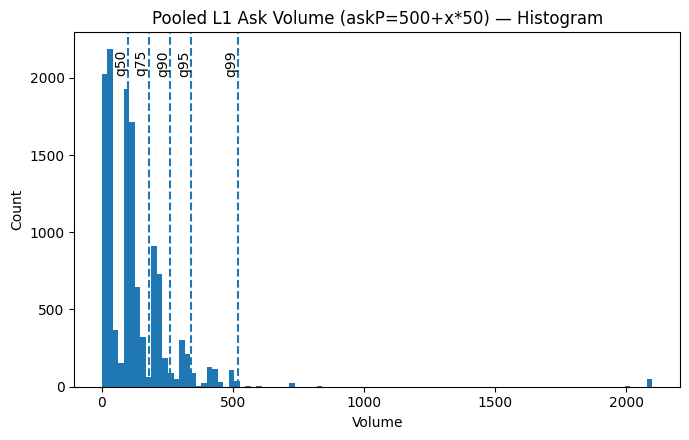

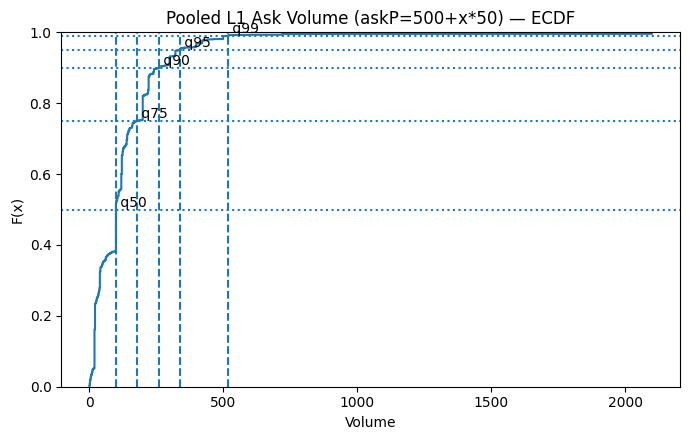

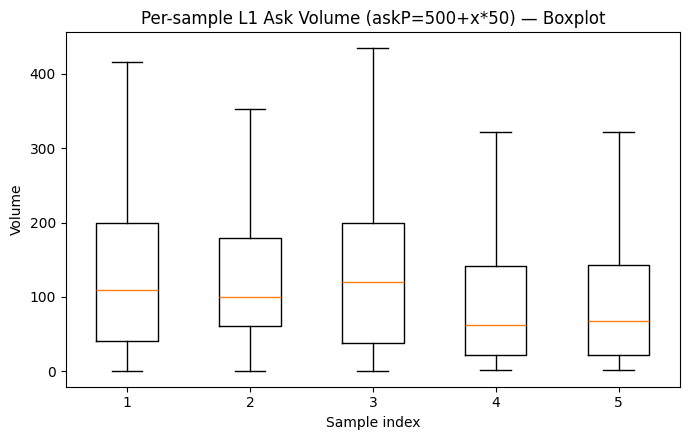

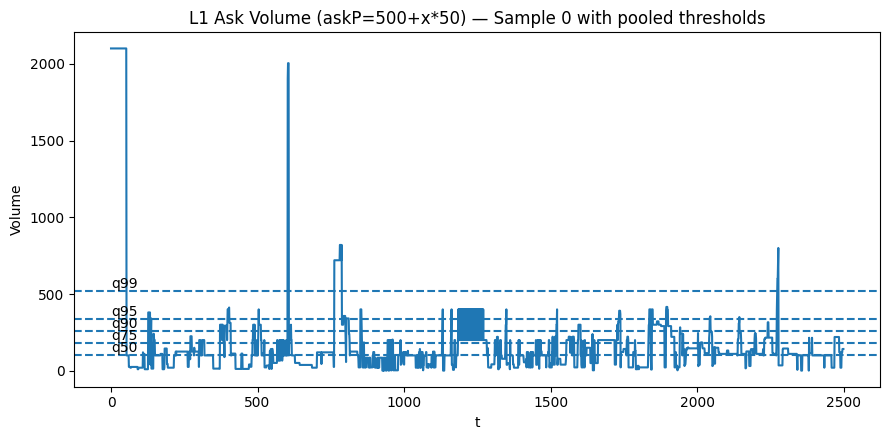

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional

# =============== 1) Авто-детект смещения и индексов интерлива ===============

def detect_interleaved_base(vec: np.ndarray) -> int:
    """
    Определяем, с какого столбца начинается паттерн [askP, askQ, bidP, bidQ, ...]:
    пробуем base=0 и base=1 и выбираем тот, где askP > bidP и Q << P.
    """
    vec = np.asarray(vec).reshape(-1)
    best = ( -1, 0)  # (score, base)
    for base in (0, 1):
        if vec.size < base + 4:
            continue
        ap, aq, bp, bq = vec[base:base+4]
        score = 0
        # askP обычно > bidP
        if ap > bp: score += 1
        # размеры (aq,bq) заметно меньше цен
        if aq >= 0 and aq < ap * 0.05: score += 1
        if bq >= 0 and bq < bp * 0.05: score += 1
        best = max(best, (score, base))
    return best[1]

def l1_indices(base: int) -> Tuple[int, int, int, int]:
    """
    Индексы для L1: askP, askQ, bidP, bidQ при данном base.
    """
    askP = base + 0
    askQ = base + 1
    bidP = base + 2
    bidQ = base + 3
    return askP, askQ, bidP, bidQ

# =============== 2) Извлечение L1 ask-объёмов для одного и многих сэмплов ===============
# Модификация: брать только те best ask, где askP = 500 + x*50 для целого x>=0

def l1_ask_volume_series_selective(
    book_array_2d: np.ndarray, 
    use_abs: bool = True, 
    price_base: float = 500, 
    price_step: float = 50, 
    tol: float = 1e-6
) -> np.ndarray:
    """
    book_array_2d: shape = (T, W), где строки — снимки книги.
    Возвращает 1D массив длины T: объём на best-ask (L1), 
    но только если askP = 500 + x*50 для целого x>=0 (иначе NaN).
    """
    if book_array_2d.size == 0:
        return np.array([])
    # Детектируем base по первой непустой строке
    first_row = None
    for t in range(book_array_2d.shape[0]):
        row = np.asarray(book_array_2d[t]).reshape(-1)
        if row.size > 0:
            first_row = row
            break
    if first_row is None:
        return np.array([])

    base = detect_interleaved_base(first_row)
    askP, askQ, _, _ = l1_indices(base)

    T = book_array_2d.shape[0]
    out = np.full(T, np.nan, dtype=float)
    for t in range(T):
        row = np.asarray(book_array_2d[t]).reshape(-1)
        if row.size <= max(askP, askQ):
            continue
        price = float(row[askP])
        # Проверяем условие: price = 500 + x*50 для целого x>=0
        x = (price - price_base) / price_step
        if x >= 0 and abs(x - round(x)) < tol:
            v = float(row[askQ])
            out[t] = abs(v) if use_abs else v
        # иначе оставляем NaN
    return out

def build_series_from_ds_selective(
    ds: List[tuple], 
    n_samples: int, 
    b_seq_position_in_tuple: int = 2,
    price_base: float = 500,
    price_step: float = 50,
    tol: float = 1e-6
) -> Tuple[List[np.ndarray], np.ndarray]:
    """
    Для ds[i][2] (твой b_seq_pv) строим ряды L1 ask объёмов,
    но только для askP = 500 + x*50 (x целое, >=0).
    Возвращает (список серий по сэмплам, единый склеенный пул без NaN).
    """
    series = []
    for i in range(n_samples):
        b_seq_pv = np.asarray(ds[i][b_seq_position_in_tuple])
        ser = l1_ask_volume_series_selective(
            b_seq_pv, 
            use_abs=True, 
            price_base=price_base, 
            price_step=price_step, 
            tol=tol
        )
        series.append(ser)
    pooled = np.concatenate([s[~np.isnan(s)] for s in series if s.size > 0], axis=0) if series else np.array([])
    return series, pooled

# =============== 3) Квантили + диагностические таблицы ===============

def compute_quantiles_and_tables(series_by_sample: List[np.ndarray], pooled: np.ndarray,
                                 qs=(0.50, 0.75, 0.90, 0.95, 0.99)):
    def _clean(x): 
        x = np.asarray(x, dtype=float).reshape(-1)
        return x[~np.isnan(x)]

    pooled = _clean(pooled)
    if pooled.size == 0:
        raise RuntimeError("Pooled пуст. Проверь структуру ds[i][2] или пример строки b_seq_pv.")

    qnames = [f"q{int(q*100):02d}" for q in qs]
    pooled_q = np.quantile(pooled, qs)
    pooled_df = pd.DataFrame({"quantile": qs, "q_name": qnames, "volume": pooled_q})

    # per-sample
    rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean(s)
        if x.size == 0:
            continue
        qv = np.quantile(x, qs)
        row = {"sample": i, "count": int(x.size), "mean": float(x.mean()), "median": float(np.median(x))}
        row.update({qnames[j]: float(qv[j]) for j in range(len(qs))})
        rows.append(row)
    per_sample_df = pd.DataFrame(rows).set_index("sample").sort_index() if rows else pd.DataFrame()

    # exceedance vs pooled thresholds
    exc_rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean(s)
        if x.size == 0:
            continue
        row = {"sample": i, "count": int(x.size)}
        for j, thr in enumerate(pooled_q):
            row[qnames[j]] = float(np.mean(x >= thr))
        exc_rows.append(row)
    exceed_df = pd.DataFrame(exc_rows).set_index("sample").sort_index() if exc_rows else pd.DataFrame()

    return pooled_df, per_sample_df, exceed_df, dict(zip(qnames, map(float, pooled_q)))

# =============== 4) Визуализации ===============

def plot_all(pooled: np.ndarray, thresholds: dict, series_by_sample: List[np.ndarray]):
    def _clean(x):
        x = np.asarray(x, dtype=float).reshape(-1)
        return x[~np.isnan(x)]

    pooled = _clean(pooled)
    qnames = list(thresholds.keys())
    qvals  = [thresholds[k] for k in qnames]

    # 1) Гистограмма + вертикальные квантили
    plt.figure(figsize=(7, 4.5))
    plt.hist(pooled, bins=100)
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--')
        plt.text(v, plt.ylim()[1]*0.95, name, rotation=90, va='top', ha='right')
    plt.title("Pooled L1 Ask Volume (askP=500+x*50) — Histogram")
    plt.xlabel("Volume"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    # 2) ECDF + линии квантилей
    xs = np.sort(pooled); ys = (np.arange(xs.size) + 1) / xs.size
    plt.figure(figsize=(7, 4.5))
    plt.step(xs, ys, where='post')
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--'); 
        # горизонтальная на нужном q:
        q = float(name[1:]) / 100.0
        plt.axhline(q, linestyle=':')
        plt.text(v, q, f" {name}", va='bottom', ha='left')
    plt.ylim(0, 1)
    plt.title("Pooled L1 Ask Volume (askP=500+x*50) — ECDF")
    plt.xlabel("Volume"); plt.ylabel("F(x)")
    plt.tight_layout(); plt.show()

    # 3) Boxplot по сэмплам
    data_for_box = [_clean(s) for s in series_by_sample if _clean(s).size > 0]
    if data_for_box:
        plt.figure(figsize=(7, 4.5))
        plt.boxplot(data_for_box, showfliers=False)
        plt.title("Per-sample L1 Ask Volume (askP=500+x*50) — Boxplot")
        plt.xlabel("Sample index"); plt.ylabel("Volume")
        plt.tight_layout(); plt.show()
    else:
        print("Boxplot пропущен: нет непустых сэмплов.")

    # 4) Временной ряд для первого непустого сэмпла
    first_idx = None
    for i, s in enumerate(series_by_sample):
        x = _clean(s)
        if x.size > 0:
            first_idx = i; break
    if first_idx is not None:
        x = _clean(series_by_sample[first_idx])
        plt.figure(figsize=(9, 4.5))
        plt.plot(np.arange(x.size), x)
        for name, v in zip(qnames, qvals):
            plt.axhline(v, linestyle='--'); plt.text(0, v, name, va='bottom', ha='left')
        plt.title(f"L1 Ask Volume (askP=500+x*50) — Sample {first_idx} with pooled thresholds")
        plt.xlabel("t"); plt.ylabel("Volume")
        plt.tight_layout(); plt.show()
    else:
        print("TS график пропущен: нет непустых сэмплов.")

# =============== 5) Запуск для твоих 5 сэмплов ===============

# Можно менять параметры price_base и price_step при необходимости
series_by_sample, pooled_best_ask = build_series_from_ds_selective(
    ds=ds, 
    n_samples=5, 
    b_seq_position_in_tuple=2,
    price_base=500,
    price_step=50,
    tol=1e-6
)

print("shapes:", [s.shape for s in series_by_sample])
print("pooled length:", pooled_best_ask.shape[0])

pooled_df, per_sample_df, exceed_df, thresholds = compute_quantiles_and_tables(series_by_sample, pooled_best_ask)

print("\n=== POOLED QUANTILES ===")
print(pooled_df.to_string(index=False))
print("\n=== PER-SAMPLE QUANTILES ===")
print(per_sample_df if not per_sample_df.empty else "— нет непустых сэмплов —")
print("\n=== EXCEEDANCE SHARES vs POOLED THRESHOLDS ===")
print(exceed_df if not exceed_df.empty else "— нет непустых сэмплов —")
print("\nQuantile thresholds:", thresholds)

plot_all(pooled_best_ask, thresholds, series_by_sample)

shapes: [(2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (2500,), (

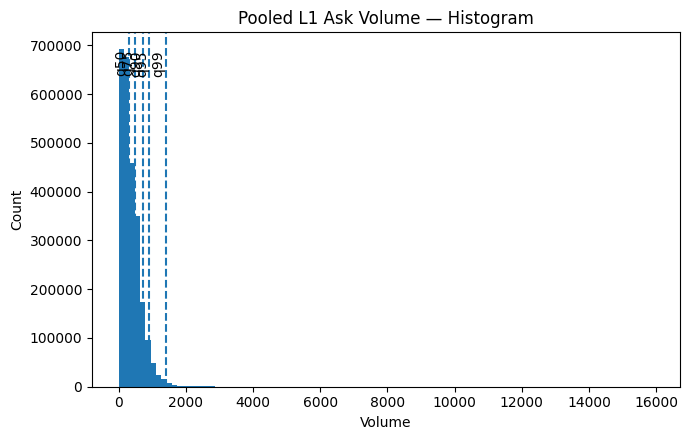

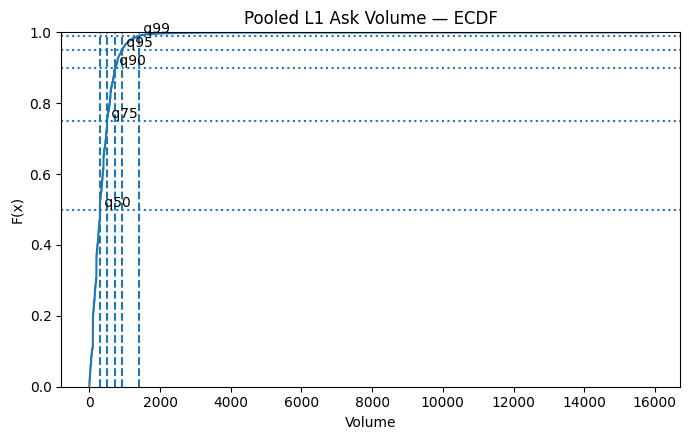

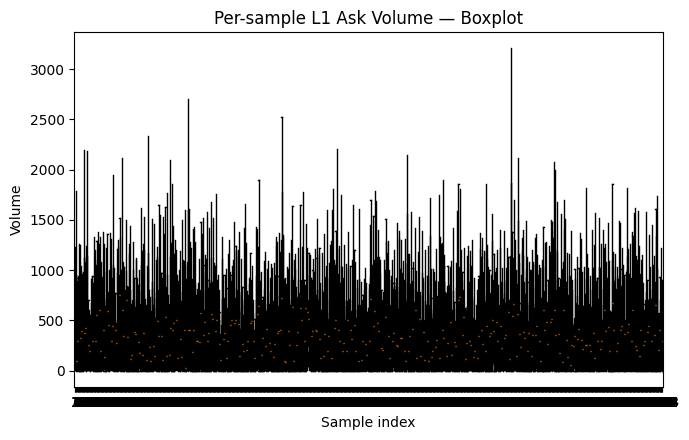

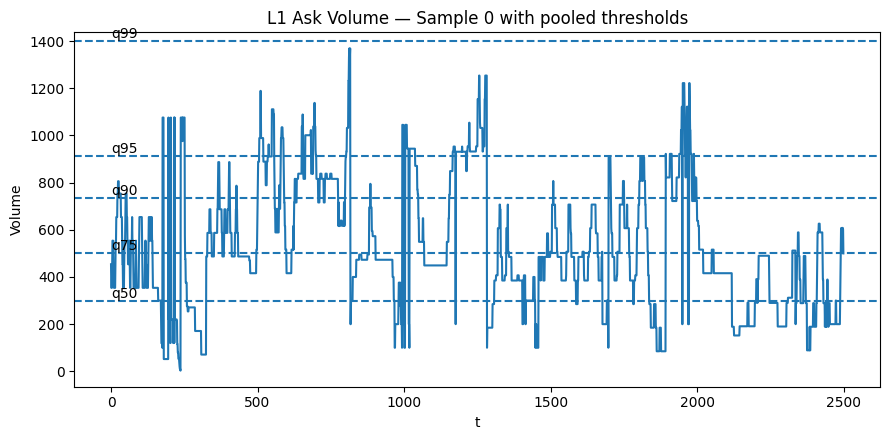

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple

# =============== 1) Авто-детект смещения и индексов интерлива ===============

def detect_interleaved_base(vec: np.ndarray) -> int:
    """
    Определяем, с какого столбца начинается паттерн [askP, askQ, bidP, bidQ, ...]:
    пробуем base=0 и base=1 и выбираем тот, где askP > bidP и Q << P.
    """
    vec = np.asarray(vec).reshape(-1)
    best = ( -1, 0)  # (score, base)
    for base in (0, 1):
        if vec.size < base + 4:
            continue
        ap, aq, bp, bq = vec[base:base+4]
        score = 0
        # askP обычно > bidP
        if ap > bp: score += 1
        # размеры (aq,bq) заметно меньше цен
        if aq >= 0 and aq < ap * 0.05: score += 1
        if bq >= 0 and bq < bp * 0.05: score += 1
        best = max(best, (score, base))
    return best[1]

def l1_indices(base: int) -> Tuple[int, int, int, int]:
    """
    Индексы для L1: askP, askQ, bidP, bidQ при данном base.
    """
    askP = base + 0
    askQ = base + 1
    bidP = base + 2
    bidQ = base + 3
    return askP, askQ, bidP, bidQ

# =============== 2) Извлечение L1 ask-объёмов для одного и многих сэмплов ===============

def l1_ask_volume_series(book_array_2d: np.ndarray, use_abs: bool = True) -> np.ndarray:
    """
    book_array_2d: shape = (T, W), где строки — снимки книги.
    Возвращает 1D массив длины T: объём на best-ask (L1).
    """
    if book_array_2d.size == 0:
        return np.array([])
    # Детектируем base по первой непустой строке
    first_row = None
    for t in range(book_array_2d.shape[0]):
        row = np.asarray(book_array_2d[t]).reshape(-1)
        if row.size > 0:
            first_row = row
            break
    if first_row is None:
        return np.array([])

    base = detect_interleaved_base(first_row)
    _, askQ, _, _ = l1_indices(base)

    T = book_array_2d.shape[0]
    out = np.full(T, np.nan, dtype=float)
    for t in range(T):
        row = np.asarray(book_array_2d[t]).reshape(-1)
        if row.size <= askQ:
            continue
        v = float(row[askQ])
        out[t] = abs(v) if use_abs else v
    return out

def build_series_from_ds(ds: List[tuple], n_samples: int, b_seq_position_in_tuple: int = 2) -> Tuple[List[np.ndarray], np.ndarray]:
    """
    Для ds[i][2] (твой b_seq_pv) строим ряды L1 ask объёмов.
    Возвращает (список серий по сэмплам, единый склеенный пул без NaN).
    """
    series = []
    for i in range(n_samples):
        b_seq_pv = np.asarray(ds[i][b_seq_position_in_tuple])
        ser = l1_ask_volume_series(b_seq_pv, use_abs=True)
        series.append(ser)
    pooled = np.concatenate([s[~np.isnan(s)] for s in series if s.size > 0], axis=0) if series else np.array([])
    return series, pooled

# =============== 3) Квантили + диагностические таблицы ===============

def compute_quantiles_and_tables(series_by_sample: List[np.ndarray], pooled: np.ndarray,
                                 qs=(0.50, 0.75, 0.90, 0.95, 0.99)):
    def _clean(x): 
        x = np.asarray(x, dtype=float).reshape(-1)
        return x[~np.isnan(x)]

    pooled = _clean(pooled)
    if pooled.size == 0:
        raise RuntimeError("Pooled пуст. Проверь структуру ds[i][2] или пример строки b_seq_pv.")

    qnames = [f"q{int(q*100):02d}" for q in qs]
    pooled_q = np.quantile(pooled, qs)
    pooled_df = pd.DataFrame({"quantile": qs, "q_name": qnames, "volume": pooled_q})

    # per-sample
    rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean(s)
        if x.size == 0:
            continue
        qv = np.quantile(x, qs)
        row = {"sample": i, "count": int(x.size), "mean": float(x.mean()), "median": float(np.median(x))}
        row.update({qnames[j]: float(qv[j]) for j in range(len(qs))})
        rows.append(row)
    per_sample_df = pd.DataFrame(rows).set_index("sample").sort_index() if rows else pd.DataFrame()

    # exceedance vs pooled thresholds
    exc_rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean(s)
        if x.size == 0:
            continue
        row = {"sample": i, "count": int(x.size)}
        for j, thr in enumerate(pooled_q):
            row[qnames[j]] = float(np.mean(x >= thr))
        exc_rows.append(row)
    exceed_df = pd.DataFrame(exc_rows).set_index("sample").sort_index() if exc_rows else pd.DataFrame()

    return pooled_df, per_sample_df, exceed_df, dict(zip(qnames, map(float, pooled_q)))

# =============== 4) Визуализации ===============

def plot_all(pooled: np.ndarray, thresholds: dict, series_by_sample: List[np.ndarray]):
    def _clean(x):
        x = np.asarray(x, dtype=float).reshape(-1)
        return x[~np.isnan(x)]

    pooled = _clean(pooled)
    qnames = list(thresholds.keys())
    qvals  = [thresholds[k] for k in qnames]

    # 1) Гистограмма + вертикальные квантили
    plt.figure(figsize=(7, 4.5))
    plt.hist(pooled, bins=100)
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--')
        plt.text(v, plt.ylim()[1]*0.95, name, rotation=90, va='top', ha='right')
    plt.title("Pooled L1 Ask Volume — Histogram")
    plt.xlabel("Volume"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    # 2) ECDF + линии квантилей
    xs = np.sort(pooled); ys = (np.arange(xs.size) + 1) / xs.size
    plt.figure(figsize=(7, 4.5))
    plt.step(xs, ys, where='post')
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--'); 
        # горизонтальная на нужном q:
        q = float(name[1:]) / 100.0
        plt.axhline(q, linestyle=':')
        plt.text(v, q, f" {name}", va='bottom', ha='left')
    plt.ylim(0, 1)
    plt.title("Pooled L1 Ask Volume — ECDF")
    plt.xlabel("Volume"); plt.ylabel("F(x)")
    plt.tight_layout(); plt.show()

    # 3) Boxplot по сэмплам
    data_for_box = [_clean(s) for s in series_by_sample if _clean(s).size > 0]
    if data_for_box:
        plt.figure(figsize=(7, 4.5))
        plt.boxplot(data_for_box, showfliers=False)
        plt.title("Per-sample L1 Ask Volume — Boxplot")
        plt.xlabel("Sample index"); plt.ylabel("Volume")
        plt.tight_layout(); plt.show()
    else:
        print("Boxplot пропущен: нет непустых сэмплов.")

    # 4) Временной ряд для первого непустого сэмпла
    first_idx = None
    for i, s in enumerate(series_by_sample):
        x = _clean(s)
        if x.size > 0:
            first_idx = i; break
    if first_idx is not None:
        x = _clean(series_by_sample[first_idx])
        plt.figure(figsize=(9, 4.5))
        plt.plot(np.arange(x.size), x)
        for name, v in zip(qnames, qvals):
            plt.axhline(v, linestyle='--'); plt.text(0, v, name, va='bottom', ha='left')
        plt.title(f"L1 Ask Volume — Sample {first_idx} with pooled thresholds")
        plt.xlabel("t"); plt.ylabel("Volume")
        plt.tight_layout(); plt.show()
    else:
        print("TS график пропущен: нет непустых сэмплов.")

# =============== 5) Запуск для всех sample_i ===============

# sample_i должен быть определён выше (например, в предыдущей ячейке)
# sample_i — это список списков индексов, например: [[8210, 7558, ...], [4347, ...], ...]
# Мы хотим обработать все эти индексы, то есть все сэмплы из sample_i

# Соберём все индексы из sample_i в один плоский список (без сортировки, с сохранением порядка и возможными дублями)
all_sample_indices = []
for sublist in sample_i:
    all_sample_indices.extend(sublist)

# Теперь обработаем все эти индексы
series_by_sample = []
for idx in all_sample_indices:
    b_seq_pv = np.asarray(ds[idx][2])
    ser = l1_ask_volume_series(b_seq_pv, use_abs=True)
    series_by_sample.append(ser)
pooled_best_ask = np.concatenate([s[~np.isnan(s)] for s in series_by_sample if s.size > 0], axis=0) if series_by_sample else np.array([])

print("shapes:", [s.shape for s in series_by_sample])
print("pooled length:", pooled_best_ask.shape[0])

pooled_df, per_sample_df, exceed_df, thresholds = compute_quantiles_and_tables(series_by_sample, pooled_best_ask)

print("\n=== POOLED QUANTILES ===")
print(pooled_df.to_string(index=False))
print("\n=== PER-SAMPLE QUANTILES ===")
print(per_sample_df if not per_sample_df.empty else "— нет непустых сэмплов —")
print("\n=== EXCEEDANCE SHARES vs POOLED THRESHOLDS ===")
print(exceed_df if not exceed_df.empty else "— нет непустых сэмплов —")
print("\nQuantile thresholds:", thresholds)

plot_all(pooled_best_ask, thresholds, series_by_sample)

EXEC (combined) counts by sample: [19, 16, 73, 18, 40, 33, 42, 27, 47, 72, 33, 24, 17, 36, 11, 43, 30, 16, 21, 56, 48, 18, 82, 38, 19, 42, 110, 22, 18, 53, 14, 15, 31, 29, 25, 70, 58, 13, 45, 13, 66, 33, 20, 48, 14, 4, 16, 36, 25, 20, 116, 14, 38, 74, 50, 43, 27, 55, 27, 9, 46, 30, 38, 53, 12, 113, 34, 73, 15, 84, 31, 14, 13, 20, 35, 125, 53, 19, 84, 50, 40, 58, 27, 67, 40, 35, 37, 16, 29, 38, 48, 10, 26, 25, 40, 31, 31, 42, 26, 6, 14, 20, 80, 34, 55, 26, 68, 28, 57, 57, 21, 33, 12, 28, 30, 36, 38, 27, 44, 39, 39, 52, 42, 108, 10, 16, 49, 48, 151, 16, 20, 24, 14, 20, 84, 34, 32, 19, 22, 11, 17, 32, 30, 14, 52, 9, 41, 19, 33, 39, 69, 5, 18, 58, 54, 19, 82, 19, 90, 25, 22, 104, 10, 28, 25, 53, 80, 21, 35, 163, 63, 19, 32, 38, 18, 23, 7, 27, 68, 6, 27, 14, 14, 9, 82, 27, 26, 25, 31, 30, 18, 36, 60, 16, 39, 21, 37, 247, 23, 94, 41, 13, 44, 28, 47, 48, 29, 24, 22, 23, 137, 39, 16, 23, 40, 38, 24, 19, 1, 61, 23, 60, 28, 74, 30, 67, 38, 40, 40, 26, 53, 32, 35, 20, 38, 25, 40, 35, 201, 47, 73,

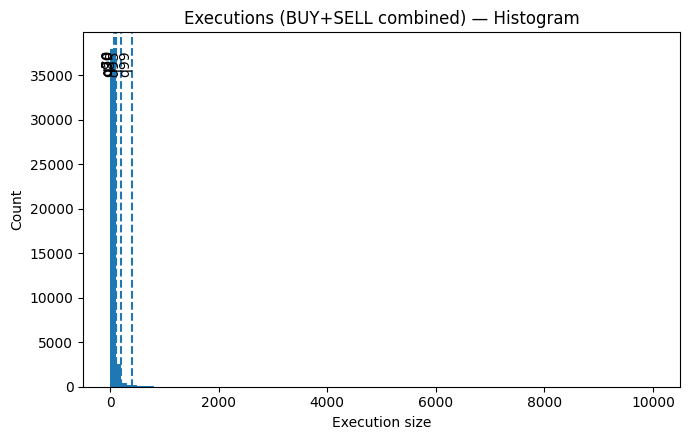

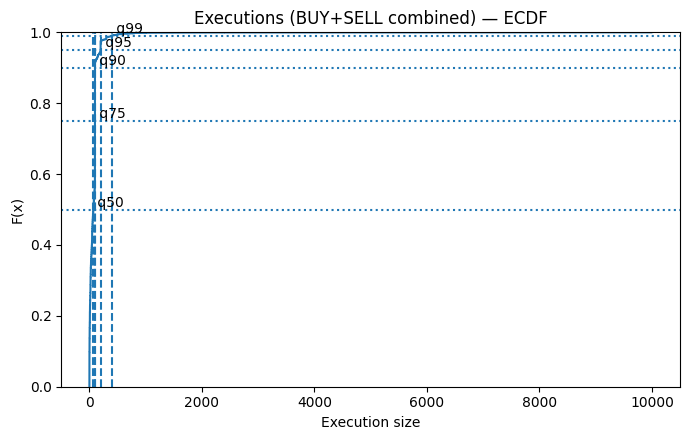

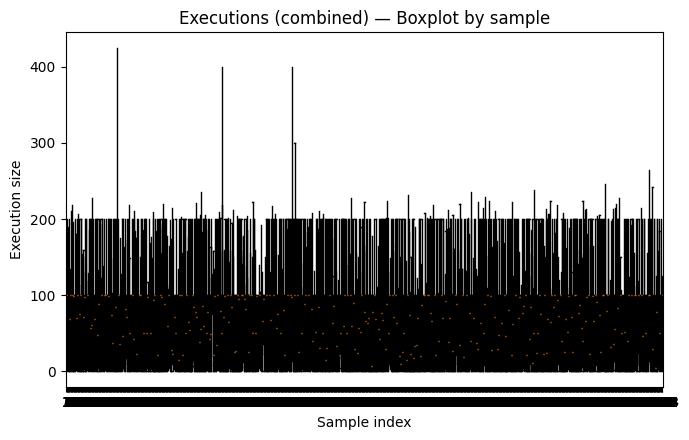

In [24]:
# ========= EXECUTION VOLUMES: BUY+SELL COMBINED — FULL CELL =========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- CONFIG (под твои данные) --------------------
EVENT_TYPE_COL = 1   # колонка с типом события
DIR_COL        = 2   # колонка со стороной: 1=Buy, 0=Sell (не используется в комбинир.)
SIZE_COL       = 5   # колонка с размером исполнения
EXEC_CODE      = 4   # !!! Важно: Execution = 4 (1=Limit, 2=PartialCancel, 3=Delete, 4=Execution)
INVALID_SENTINEL = -9999

# где в ds лежит массив сообщений (msg_seq_raw)
MSG_POS_IN_DS = 3

# если m_dict отсутствует, попробовать собрать из ds + sample_i
TRY_BUILD_M_DICT = True

# -------------------- utils --------------------
def _clean_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1)
    return x[~np.isnan(x)]

def pooled_from_series(series_list):
    return (np.concatenate([_clean_1d(s) for s in series_list if np.asarray(s).size > 0], axis=0)
            if series_list else np.array([]))

def compute_quantiles_and_tables(series_by_sample, pooled, qs=(0.50,0.75,0.90,0.95,0.99)):
    pooled = _clean_1d(pooled)
    if pooled.size == 0:
        raise RuntimeError("Pooled пуст — нет валидных исполнений. Проверь m_dict/колонки/EXEC_CODE.")
    qnames = [f"q{int(q*100):02d}" for q in qs]
    pooled_q = np.quantile(pooled, qs)
    pooled_df = pd.DataFrame({"quantile": qs, "q_name": qnames, "volume": pooled_q})

    rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean_1d(s)
        if x.size == 0:
            continue
        qv = np.quantile(x, qs)
        row = {"sample": i, "count": int(x.size), "mean": float(x.mean()), "median": float(np.median(x))}
        row.update({qnames[j]: float(qv[j]) for j in range(len(qs))})
        rows.append(row)
    per_sample_df = (pd.DataFrame(rows).set_index("sample").sort_index()) if rows else pd.DataFrame()

    exc_rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean_1d(s)
        if x.size == 0:
            continue
        row = {"sample": i, "count": int(x.size)}
        for j, thr in enumerate(pooled_q):
            row[qnames[j]] = float(np.mean(x >= thr))
        exc_rows.append(row)
    exceed_df = (pd.DataFrame(exc_rows).set_index("sample").sort_index()) if exc_rows else pd.DataFrame()

    thresholds = dict(zip(qnames, map(float, pooled_q)))
    return pooled_df, per_sample_df, exceed_df, thresholds

def plot_hist_ecdf(pooled, thresholds, title_prefix):
    pooled = _clean_1d(pooled)
    qnames = list(thresholds.keys())
    qvals  = [thresholds[k] for k in qnames]

    # Histogram
    plt.figure(figsize=(7, 4.5))
    plt.hist(pooled, bins=100)
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--')
        plt.text(v, plt.ylim()[1]*0.95, name, rotation=90, va='top', ha='right')
    plt.title(f"{title_prefix} — Histogram")
    plt.xlabel("Execution size"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    # ECDF
    xs = np.sort(pooled)
    ys = (np.arange(xs.size) + 1) / xs.size
    plt.figure(figsize=(7, 4.5))
    plt.step(xs, ys, where='post')
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--')
        q = float(name[1:]) / 100.0
        plt.axhline(q, linestyle=':')
        plt.text(v, q, f" {name}", va='bottom', ha='left')
    plt.ylim(0, 1)
    plt.title(f"{title_prefix} — ECDF")
    plt.xlabel("Execution size"); plt.ylabel("F(x)")
    plt.tight_layout(); plt.show()

def plot_box(series_by_sample, title):
    data = [_clean_1d(s) for s in series_by_sample if _clean_1d(s).size > 0]
    if not data:
        print(f"Boxplot '{title}' пропущен: нет данных.")
        return
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data, showfliers=False)
    plt.title(title)
    plt.xlabel("Sample index"); plt.ylabel("Execution size")
    plt.tight_layout(); plt.show()

# -------------------- сборка m_dict при необходимости --------------------
g = globals()
m_dict = g.get("m_dict", None)

if (m_dict is None) and TRY_BUILD_M_DICT:
    ds = g.get("ds", None)
    sample_i = g.get("sample_i", None)
    if (ds is not None) and (sample_i is not None):
        # поддержим sample_i как список списков или как плоский список индексов
        if len(sample_i) > 0 and isinstance(sample_i[0], (list, tuple, np.ndarray)):
            flat_indices = []
            for sub in sample_i:
                flat_indices.extend(list(sub))
        else:
            flat_indices = list(sample_i)
        m_dict = {i: np.asarray(ds[idx][MSG_POS_IN_DS]) for i, idx in enumerate(flat_indices)}
        print(f"[info] m_dict построен из ds+sample_i, samples={len(m_dict)}")
    else:
        raise RuntimeError("m_dict не найден, и нет ds/sample_i для авто-сборки. "
                           "Либо передай m_dict, либо включи ds и sample_i.")

# -------------------- извлечение исполнений (BUY+SELL вместе) --------------------
def extract_exec_sizes_combined(
    m_dict: dict,
    event_type_col: int = EVENT_TYPE_COL,
    size_col: int = SIZE_COL,
    execution_code: int = EXEC_CODE,
    invalid_sentinel: int = INVALID_SENTINEL,
):
    """
    Возвращает список по сэмплам: в каждом np.ndarray лежат sizes всех Execution (обе стороны).
    """
    combined_series = []
    for k in sorted(m_dict.keys()):
        arr = np.asarray(m_dict[k])
        if arr.ndim != 2 or arr.shape[1] <= max(event_type_col, size_col):
            combined_series.append(np.array([]))
            continue

        is_exec = (arr[:, event_type_col] == execution_code)
        sizes   = arr[is_exec, size_col].astype(float)

        # чистим мусор
        if invalid_sentinel is not None:
            sizes = sizes[(sizes > 0) & (sizes != invalid_sentinel)]
        else:
            sizes = sizes[sizes > 0]

        combined_series.append(sizes)
    return combined_series

series_combined = extract_exec_sizes_combined(m_dict)
pooled_combined = pooled_from_series(series_combined)

print("EXEC (combined) counts by sample:", [np.asarray(s).size for s in series_combined])
print("pooled EXEC (combined) size:", pooled_combined.size)

# -------------------- квантили/таблицы/пороги --------------------
pooled_df_all, per_df_all, exc_df_all, thr_all = compute_quantiles_and_tables(series_combined, pooled_combined)

print("\n=== EXEC QUANTILES (BUY+SELL COMBINED) ===")
print(pooled_df_all.to_string(index=False))
print("\n=== PER-SAMPLE (COMBINED) ===")
print(per_df_all if not per_df_all.empty else "— нет непустых сэмплов —")
print("\n=== EXCEEDANCE vs POOLED (COMBINED) ===")
print(exc_df_all if not exc_df_all.empty else "— нет непустых сэмплов —")
print("\nCOMBINED thresholds:", thr_all)

# -------------------- визуализации --------------------
plot_hist_ecdf(pooled_combined, thr_all, "Executions (BUY+SELL combined)")
plot_box(series_by_sample=series_combined, title="Executions (combined) — Boxplot by sample")

# -------------------- пороги для стратегии --------------------
# Пример: берём общий τ_all = thr_all['q75'] и используем правило:
# size_t = min(available_side_t, τ_all)
# (для Buy сравниваем с ask-стороной книги, для Sell — с bid-стороной)

ASK shapes (all): [(2500,), (2500,), (2500,), (2500,), (2500,)] ... total 8688
BID shapes (all): [(2500,), (2500,), (2500,), (2500,), (2500,)] ... total 8688
COMBINED union (ALL) per-sample counts: [5000, 5000, 5000, 5000, 5000] ... (showing first 5)
pooled union (ALL) size: 43440000

=== L1 DEPTH QUANTILES — COMBINED (ASK ∪ BID), ALL TIMES ===
 quantile q_name  volume
     0.50    q50   300.0
     0.75    q75   483.0
     0.90    q90   695.0
     0.95    q95   866.0
     0.99    q99  1400.0

=== PER-SAMPLE (COMBINED union, ALL) — head ===
        count      mean  median    q50    q75    q90    q95     q99
sample                                                             
0        5000  174.3986   100.0  100.0  200.0  300.0  400.0  2100.0
1        5000  168.6120   101.0  101.0  200.0  406.0  506.0  1000.0
2        5000  131.6656   105.0  105.0  200.0  225.1  322.0   520.0
3        5000  121.5634   100.0  100.0  200.0  300.0  311.0   422.0
4        5000  158.4764   106.0  106.0  200.0 

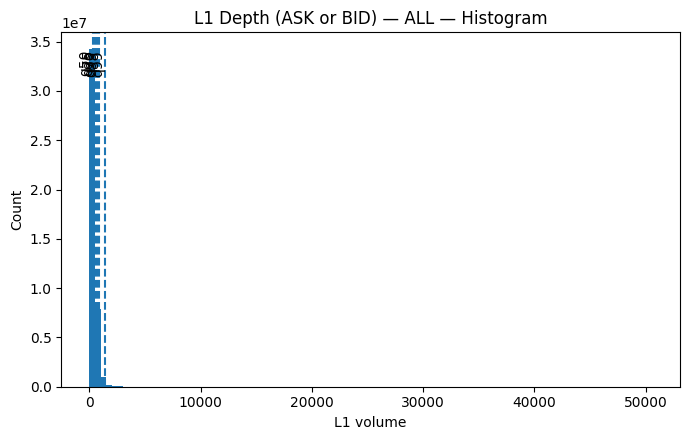

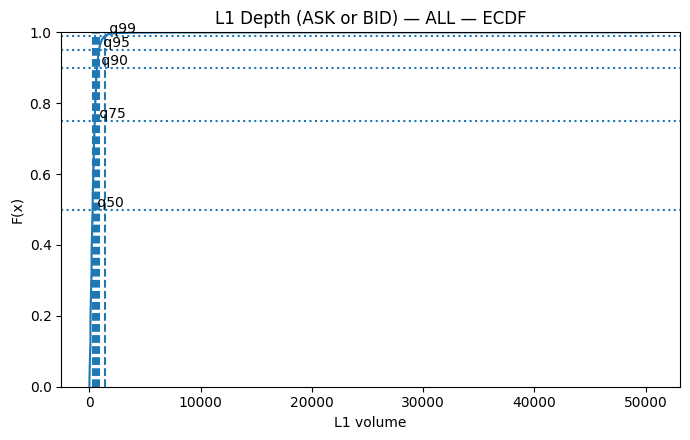


SUM (ASK+Bid, ALL) per-sample counts (head): [2500, 2500, 2500, 2500, 2500] ...

=== L1 TOTAL DEPTH QUANTILES — SUM (ASK + BID), ALL TIMES ===
 quantile q_name  volume
     0.50    q50   610.0
     0.75    q75   898.0
     0.90    q90  1232.0
     0.95    q95  1495.0
     0.99    q99  2315.0

=== PER-SAMPLE (SUM, ALL) — head ===
        count      mean  median    q50    q75    q90      q95      q99
sample                                                                
0        2500  348.7972   223.5  223.5  345.5  582.0  1659.00  2320.00
1        2500  337.2240   263.0  263.0  428.0  679.0   728.25  1314.01
2        2500  263.3312   226.0  226.0  330.0  464.7   606.00   714.06
3        2500  243.1268   222.0  222.0  339.0  428.0   500.00   628.00
4        2500  316.9528   251.0  251.0  385.0  772.0   850.00   930.26

SUM (ALL) thresholds (ask+bid): {'q50': 610.0, 'q75': 898.0, 'q90': 1232.0, 'q95': 1495.0, 'q99': 2315.0}


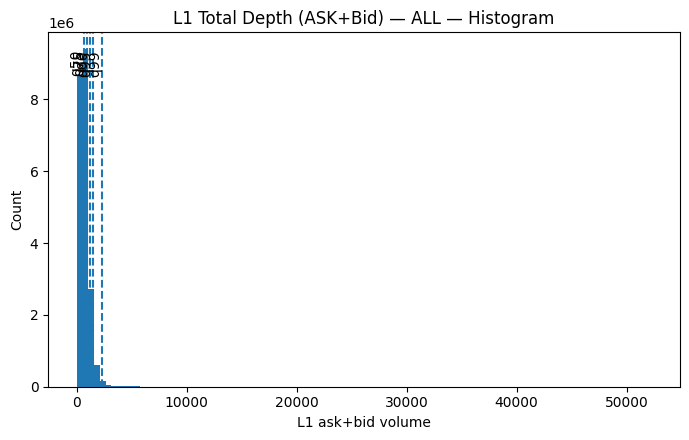

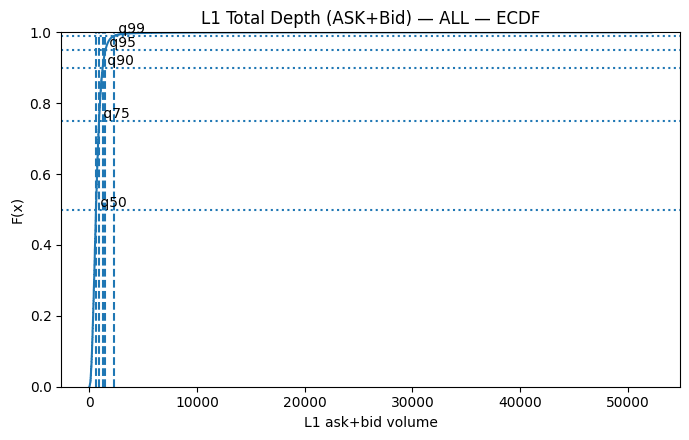


=== L1 DEPTH QUANTILES — COMBINED (ASK ∪ BID), GRID t=500+50x ===
 quantile q_name  volume
     0.50    q50   300.0
     0.75    q75   484.0
     0.90    q90   695.0
     0.95    q95   866.0
     0.99    q99  1402.0

COMBINED (GRID) thresholds: {'q50': 300.0, 'q75': 484.0, 'q90': 695.0, 'q95': 866.0, 'q99': 1402.0}


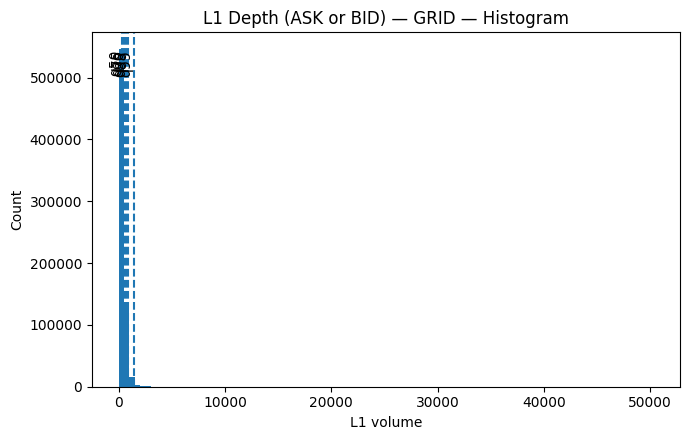

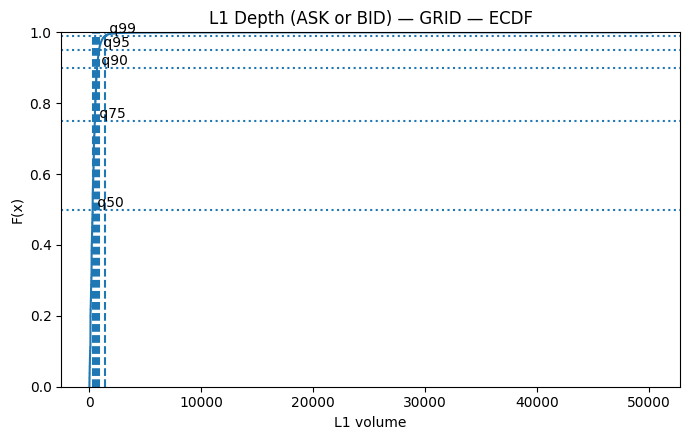


=== L1 TOTAL DEPTH QUANTILES — SUM (ASK + BID), GRID t=500+50x ===
 quantile q_name  volume
     0.50    q50  610.00
     0.75    q75  898.00
     0.90    q90 1233.00
     0.95    q95 1497.00
     0.99    q99 2310.81

SUM (GRID) thresholds: {'q50': 610.0, 'q75': 898.0, 'q90': 1233.0, 'q95': 1497.0, 'q99': 2310.8099999999977}


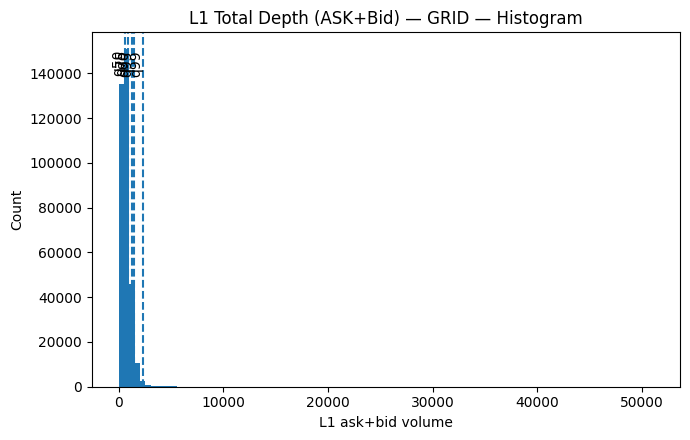

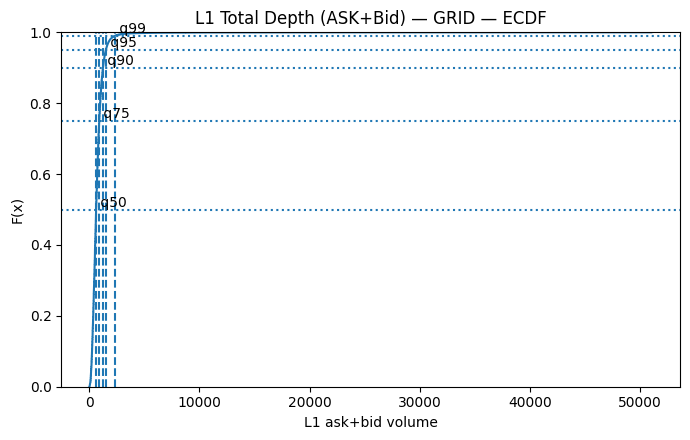

In [26]:
# ========= L1 BOOK DEPTH QUANTILES over ALL samples & times + GRID(t=500+50x) =========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, List

# -------------------- CONFIG --------------------
BSEQ_POS_IN_DS = 2      # где лежит b_seq_pv в ds[i]
USE_ABS = True          # брать |объёмы|
QS = (0.50, 0.75, 0.90, 0.95, 0.99)

# GRID: брать только моменты t = GRID_START + k*GRID_STEP (k=0,1,2,...) в пределах длины ряда
GRID_START = 500
GRID_STEP  = 50

# -------------------- helpers --------------------
def detect_interleaved_base(vec: np.ndarray) -> int:
    """
    Авто-детект offset'а, с которого начинается интерлив [askP, askQ, bidP, bidQ, ...].
    Проверяем base∈{0,1} на первой валидной строке: ap>bp и Q << P.
    """
    vec = np.asarray(vec).reshape(-1)
    best = (-1, 0)  # (score, base)
    for base in (0, 1):
        if vec.size < base + 4:
            continue
        ap, aq, bp, bq = vec[base:base+4]
        score = 0
        if ap > bp: score += 1
        if aq >= 0 and aq < ap * 0.05: score += 1
        if bq >= 0 and bq < bp * 0.05: score += 1
        if score > best[0]:
            best = (score, base)
    return best[1]

def l1_indices(base: int) -> Tuple[int, int, int, int]:
    """Возвращает индексы L1: askP, askQ, bidP, bidQ для данного base."""
    askP = base + 0
    askQ = base + 1
    bidP = base + 2
    bidQ = base + 3
    return askP, askQ, bidP, bidQ

def l1_side_series(book_2d: np.ndarray, side: str, use_abs: bool = True) -> np.ndarray:
    """
    Возвращает 1D ряд L1-объёмов для указанной стороны: side ∈ {"ask","bid"}.
    Авто-детект base по первой валидной строке в данном сэмпле; берём колонку askQ или bidQ.
    """
    if book_2d.size == 0:
        return np.array([])
    # первая валидная строка
    first_row = None
    for t in range(book_2d.shape[0]):
        r = np.asarray(book_2d[t]).reshape(-1)
        if r.size > 0:
            first_row = r
            break
    if first_row is None:
        return np.array([])

    base = detect_interleaved_base(first_row)
    _, askQ, _, bidQ = l1_indices(base)
    col = askQ if side == "ask" else bidQ

    T = book_2d.shape[0]
    out = np.full(T, np.nan, dtype=float)
    for t in range(T):
        row = np.asarray(book_2d[t]).reshape(-1)
        if row.size <= col:
            continue
        v = float(row[col])
        out[t] = abs(v) if use_abs else v
    return out

def _clean_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1)
    return x[~np.isnan(x)]

def pooled_from_series(series_list: List[np.ndarray]) -> np.ndarray:
    return (np.concatenate([_clean_1d(s) for s in series_list if np.asarray(s).size > 0], axis=0)
            if series_list else np.array([]))

def compute_quantiles_and_tables(series_by_sample, pooled, qs=QS):
    pooled = _clean_1d(pooled)
    if pooled.size == 0:
        raise RuntimeError("Pooled пуст — нет валидных значений. Проверь структуру b_seq_pv.")
    qnames = [f"q{int(q*100):02d}" for q in qs]
    pooled_q = np.quantile(pooled, qs)
    pooled_df = pd.DataFrame({"quantile": qs, "q_name": qnames, "volume": pooled_q})

    rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean_1d(s)
        if x.size == 0:
            continue
        qv = np.quantile(x, qs)
        row = {"sample": i, "count": int(x.size), "mean": float(x.mean()), "median": float(np.median(x))}
        row.update({qnames[j]: float(qv[j]) for j in range(len(qs))})
        rows.append(row)
    per_sample_df = (pd.DataFrame(rows).set_index("sample").sort_index()) if rows else pd.DataFrame()

    exc_rows = []
    for i, s in enumerate(series_by_sample):
        x = _clean_1d(s)
        if x.size == 0:
            continue
        row = {"sample": i, "count": int(x.size)}
        for j, thr in enumerate(pooled_q):
            row[qnames[j]] = float(np.mean(x >= thr))
        exc_rows.append(row)
    exceed_df = (pd.DataFrame(exc_rows).set_index("sample").sort_index()) if exc_rows else pd.DataFrame()

    thresholds = dict(zip(qnames, map(float, pooled_q)))
    return pooled_df, per_sample_df, exceed_df, thresholds

def plot_hist_ecdf(pooled, thresholds, title_prefix, xlab="Volume"):
    pooled = _clean_1d(pooled)
    qnames = list(thresholds.keys())
    qvals  = [thresholds[k] for k in qnames]

    # Histogram
    plt.figure(figsize=(7, 4.5))
    plt.hist(pooled, bins=100)
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--')
        plt.text(v, plt.ylim()[1]*0.95, name, rotation=90, va='top', ha='right')
    plt.title(f"{title_prefix} — Histogram")
    plt.xlabel(xlab); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    # ECDF
    xs = np.sort(pooled)
    ys = (np.arange(xs.size) + 1) / xs.size
    plt.figure(figsize=(7, 4.5))
    plt.step(xs, ys, where='post')
    for name, v in zip(qnames, qvals):
        plt.axvline(v, linestyle='--')
        q = float(name[1:]) / 100.0
        plt.axhline(q, linestyle=':')
        plt.text(v, q, f" {name}", va='bottom', ha='left')
    plt.ylim(0, 1)
    plt.title(f"{title_prefix} — ECDF")
    plt.xlabel(xlab); plt.ylabel("F(x)")
    plt.tight_layout(); plt.show()

def plot_box(series_by_sample, title, ylab="Volume"):
    data = [_clean_1d(s) for s in series_by_sample if _clean_1d(s).size > 0]
    if not data:
        print(f"Boxplot '{title}' пропущен: нет данных.")
        return
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data, showfliers=False)
    plt.title(title)
    plt.xlabel("Sample index"); plt.ylabel(ylab)
    plt.tight_layout(); plt.show()

def sum_two_series(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Элементно суммируем с обработкой NaN. Если оба NaN → NaN."""
    a = np.asarray(a, dtype=float).reshape(-1)
    b = np.asarray(b, dtype=float).reshape(-1)
    T = min(a.size, b.size)
    a = a[:T]; b = b[:T]
    both_nan = np.isnan(a) & np.isnan(b)
    s = np.nan_to_num(a, nan=0.0) + np.nan_to_num(b, nan=0.0)
    s[both_nan] = np.nan
    return s

def subset_grid(series: np.ndarray, start: int, step: int) -> np.ndarray:
    """Выбираем значения в индексах t=start, start+step, ... < len(series)."""
    x = np.asarray(series, dtype=float).reshape(-1)
    T = x.size
    if T == 0 or start >= T:
        return np.array([])
    idx = np.arange(start, T, step, dtype=int)
    # маска на валидные индексы
    idx = idx[(idx >= 0) & (idx < T)]
    y = x[idx]
    return y

# -------------------- MAIN: извлекаем ASK/BID L1 для всех ds --------------------
g = globals()
ds = g.get("ds", None)
if ds is None:
    raise RuntimeError("Ожидаю, что ds определён в окружении.")

N = len(ds)

ask_series_all = []
bid_series_all = []
for i in range(N):
    b_seq_pv = np.asarray(ds[i][BSEQ_POS_IN_DS])
    ask_series_all.append(l1_side_series(b_seq_pv, side="ask", use_abs=USE_ABS))
    bid_series_all.append(l1_side_series(b_seq_pv, side="bid", use_abs=USE_ABS))

print("ASK shapes (all):", [s.shape for s in ask_series_all[:5]], "... total", len(ask_series_all))
print("BID shapes (all):", [s.shape for s in bid_series_all[:5]], "... total", len(bid_series_all))

# -------------------- Variant A: COMBINED (ASK ∪ BID), ALL TIMES --------------------
series_union_all = [
    np.concatenate([_clean_1d(a), _clean_1d(b)]) for a, b in zip(ask_series_all, bid_series_all)
]
pooled_union_all = pooled_from_series(series_union_all)

print("COMBINED union (ALL) per-sample counts:", [len(s) for s in series_union_all[:5]], "... (showing first 5)")
print("pooled union (ALL) size:", len(pooled_union_all))

pooled_df_union_all, per_df_union_all, exc_df_union_all, thr_union_all = compute_quantiles_and_tables(
    series_union_all, pooled_union_all, qs=QS
)

print("\n=== L1 DEPTH QUANTILES — COMBINED (ASK ∪ BID), ALL TIMES ===")
print(pooled_df_union_all.to_string(index=False))
print("\n=== PER-SAMPLE (COMBINED union, ALL) — head ===")
print(per_df_union_all.head() if not per_df_union_all.empty else "— нет непустых сэмплов —")
print("\nCOMBINED (ALL) thresholds:", thr_union_all)

plot_hist_ecdf(pooled_union_all, thr_union_all, "L1 Depth (ASK or BID) — ALL", xlab="L1 volume")

# -------------------- Variant B: SUM (ASK + BID), ALL TIMES --------------------
series_sum_all = [sum_two_series(a, b) for a, b in zip(ask_series_all, bid_series_all)]
pooled_sum_all = pooled_from_series(series_sum_all)

print("\nSUM (ASK+Bid, ALL) per-sample counts (head):", [len(_clean_1d(s)) for s in series_sum_all[:5]], "...")

pooled_df_sum_all, per_df_sum_all, exc_df_sum_all, thr_sum_all = compute_quantiles_and_tables(
    series_sum_all, pooled_sum_all, qs=QS
)

print("\n=== L1 TOTAL DEPTH QUANTILES — SUM (ASK + BID), ALL TIMES ===")
print(pooled_df_sum_all.to_string(index=False))
print("\n=== PER-SAMPLE (SUM, ALL) — head ===")
print(per_df_sum_all.head() if not per_df_sum_all.empty else "— нет непустых сэмплов —")
print("\nSUM (ALL) thresholds (ask+bid):", thr_sum_all)

plot_hist_ecdf(pooled_sum_all, thr_sum_all, "L1 Total Depth (ASK+Bid) — ALL", xlab="L1 ask+bid volume")

# -------------------- GRID subset: t = 500 + 50*x --------------------
ask_series_grid = [subset_grid(s, start=GRID_START, step=GRID_STEP) for s in ask_series_all]
bid_series_grid = [subset_grid(s, start=GRID_START, step=GRID_STEP) for s in bid_series_all]

# COMBINED (union) on GRID
series_union_grid = [
    np.concatenate([_clean_1d(a), _clean_1d(b)]) for a, b in zip(ask_series_grid, bid_series_grid)
]
pooled_union_grid = pooled_from_series(series_union_grid)

pooled_df_union_grid, per_df_union_grid, exc_df_union_grid, thr_union_grid = compute_quantiles_and_tables(
    series_union_grid, pooled_union_grid, qs=QS
)

print("\n=== L1 DEPTH QUANTILES — COMBINED (ASK ∪ BID), GRID t=500+50x ===")
print(pooled_df_union_grid.to_string(index=False))
print("\nCOMBINED (GRID) thresholds:", thr_union_grid)

plot_hist_ecdf(pooled_union_grid, thr_union_grid, "L1 Depth (ASK or BID) — GRID", xlab="L1 volume")

# SUM (ask+bid) on GRID
def sum_on_grid(a_full: np.ndarray, b_full: np.ndarray, start: int, step: int) -> np.ndarray:
    a = subset_grid(a_full, start, step)
    b = subset_grid(b_full, start, step)
    # одинаковые индексы сетки → просто покомпонентная сумма
    T = min(a.size, b.size)
    if T == 0:
        return np.array([])
    s = a[:T] + b[:T]
    return s

series_sum_grid = [sum_on_grid(a, b, GRID_START, GRID_STEP) for a, b in zip(ask_series_all, bid_series_all)]
pooled_sum_grid = pooled_from_series(series_sum_grid)

pooled_df_sum_grid, per_df_sum_grid, exc_df_sum_grid, thr_sum_grid = compute_quantiles_and_tables(
    series_sum_grid, pooled_sum_grid, qs=QS
)

print("\n=== L1 TOTAL DEPTH QUANTILES — SUM (ASK + BID), GRID t=500+50x ===")
print(pooled_df_sum_grid.to_string(index=False))
print("\nSUM (GRID) thresholds:", thr_sum_grid)

plot_hist_ecdf(pooled_sum_grid, thr_sum_grid, "L1 Total Depth (ASK+Bid) — GRID", xlab="L1 ask+bid volume")

# -------------------- Готовые пороги для стратегии --------------------
# τ_union_all  = thr_union_all['q75']       # единый порог по «любой стороне», все моменты
# τ_union_grid = thr_union_grid['q75']      # единый порог по «любой стороне», только GRID
# τ_sum_all    = thr_sum_all['q75']         # по суммарной L1-глубине, все моменты
# τ_sum_grid   = thr_sum_grid['q75']        # по суммарной L1-глубине, только GRID